## Einführung

Neuronen empfangen über Synapsen zahlreiche exzitatorische und inhibitorische Inputs von anderen Neuronen. Wenn diese Eingaben einen bestimmten Schwellenwert überschreiten, feuert das Neuron und erzeugt ein Aktionspotential, auch Spike genannt. Da Aktionspotentiale sehr kurzlebig sind, können wir diese nicht messen. Stattdessen können wir die etwas langsameren synaptischen Ströme messen, zum Beispiel als **Local Field Potentials (LFP)** oder **EEG**.

Wenn das Spiking einer Gruppe von Neuronen unregelmäßig ist, zeigt die Summe ihrer synaptischen Ströme ein unregelmäßiges Muster. Wenn sich ihre Aktivität zeitlich anpasst, beobachten wir synchronisiertes Verhalten in Form einer Oszillation. Ein klassisches Beispiel dafür ist das Konzept der **Leerlauf-Rhythmen (idle rhythms)**. Wenn eine Gehirnregion im Moment keinerlei Informationen aktiv verarbeitet, neigen die Neuronen dieser Region dazu, sich zu einer langsamen, regelmäßigen Oszillation zu synchronisieren — fast wie Standby-Modus. Sobald die Region durch eine Aufgabe oder einen Reiz aktiviert wird, bricht diese Synchronisation zusammen und die Oszillation verschwindet. Diese Unterdrückung einer Oszillation durch aktive Informationsverarbeitung wird als **ereignisbezogene Desynchronisation / event-related desynchronization (ERD)** bezeichnet.

In diesem Notebook werden wir genau diesen Effekt anhand eines EEG Datensatzes untersuchen. Dafür laden wir zunächst MNE, eine hilfreiche Bibliothek zur Untersuchung von neuronalen Signalen, und den EEGBCI Datensatz.

In [52]:
# importieren der bibliotheken und des eeg datensatzes
import mne
from mne.datasets import eegbci
import matplotlib.pyplot as plt
import numpy as np

Der EEG Datensatz umfasst Daten von 109 Probanden, die an einem Experiment teilgenommen haben. Einer der Aufgaben des Experiments war, still zu sitzen und dabei die Augen geöffnet zu haben. Danach wurde die Aufgabe wiederholt, aber diesmal mit geschlossenen Augen. 

Was passiert, wenn Sie Ihre Augen schließen? Sie sehen nichts mehr, sprich: Sie nehmen keinerlei visuellen Reize mehr wahr. Jetzt, wo Sie erfahren haben, was im Gehirn passiert, wenn gerade keine Informationen aktiv verarbeitet werden, können Sie vielleicht erahnen, wonach wir suchen?

In [42]:
# wähle sie einen probanden (1-109) und die entsprechenden runs aus
subject = 10
runs = [1, 2]  # 1 = augen offen, 2 = augen geschlossen

# laden sie die daten und erstellen sie ein raw objekt
files = eegbci.load_data(subject, runs)
raws = [mne.io.read_raw_edf(f, preload=True) for f in files]

raw_eo = raws[0]  # augen offen
raw_ec = raws[1]  # augen geschlossen

Download complete in 17s (2.4 MB)
Extracting EDF parameters from /Users/elsahh/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S010/S010R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Extracting EDF parameters from /Users/elsahh/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S010/S010R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...


In [43]:
# zeigen sie nützliche informationen über das raw objekt an, z.B. die sampling rate, die kanäle, die dauer der aufnahme, etc.
print(raw_eo.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


Es ist hilfreich zu wissen, wo sich welcher Kanal befindet. Daher werden wir die sogenannte EEG Montage visualisieren.

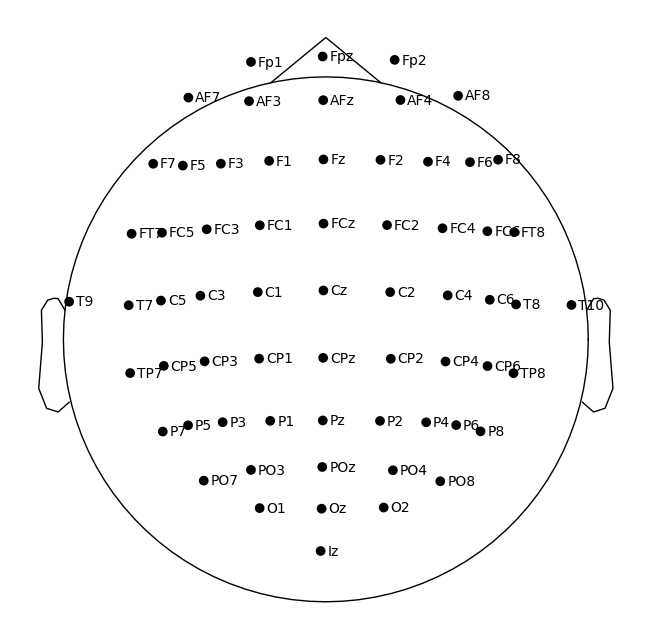

In [47]:
# erstellen sie eine standard eeg montage
montage = mne.channels.make_standard_montage('standard_1005')

# standardisieren sie die namen der kanäle und ordnen sie die kanäle der montage zu
for raw in [raw_eo, raw_ec]:
    eegbci.standardize(raw)
    raw.set_montage(montage)

# plotten sie die montage mit den kanälen
_ = raw_eo.plot_sensors(show_names=True)

Als nächstes wollen wir die Signale vom Zeitbereich in den Frequenzbereich transformieren und uns das Leistungsspektrum (power spectrum) anschauen.

In [93]:
# berechnen sie die leistungsspektren für beide bedingungen (augen offen und augen geschlossen) im frequenzbereich von 1-40 Hz
fmin, fmax = 1, 40
n_fft = 1024

psd_eo = raw_eo.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=n_fft)
psd_ec = raw_ec.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=n_fft)

Effective window size : 6.400 (s)
Effective window size : 6.400 (s)


Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


Text(0.5, 0.98, 'Augen geschlossen')

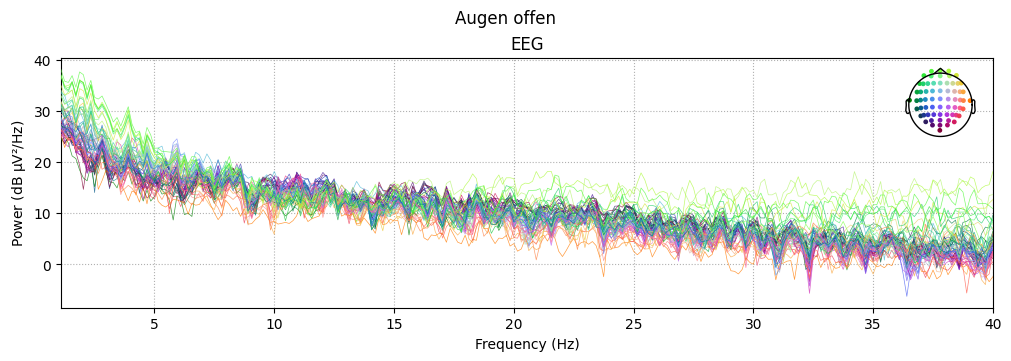

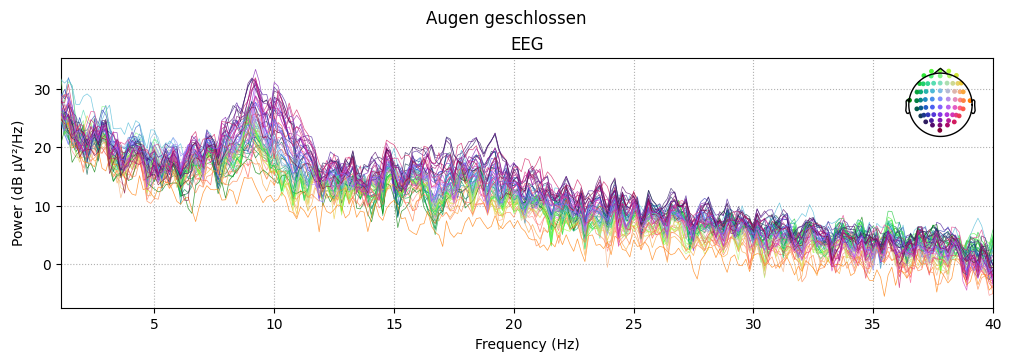

In [95]:
fig1 = psd_eo.plot(show=False)
fig1.suptitle("Augen offen")
fig2 = psd_ec.plot(show=False)
fig2.suptitle("Augen geschlossen")

Die beiden Plots zeigen die Leistungsspektren aller Kanäle für die einzelnen Bedingungen. Es ist etwas unübersichtlich, aber vielleicht sehen Sie trotzdem schon einen Unterschied zwischen beiden Spektren? Wenn wir uns die Mittelwerte aller Kanäle anschauen, wird es etwas deutlicher.

Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


Text(0.5, 0.98, 'Augen geschlossen')

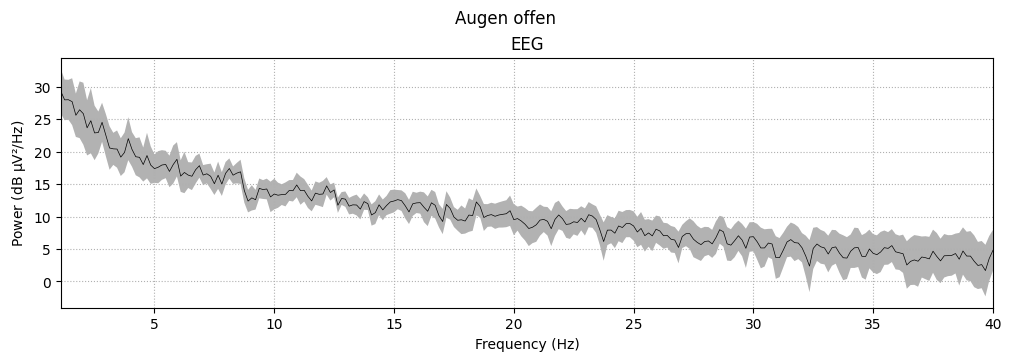

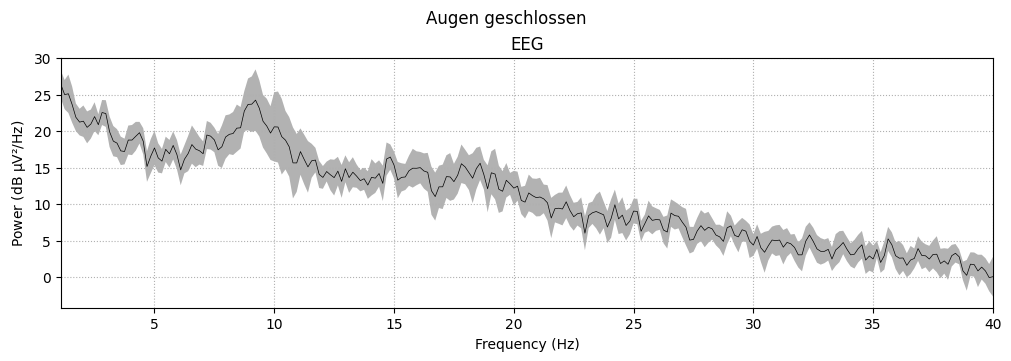

In [94]:
fig1 = psd_eo.plot(show=False, average=True)
fig1.suptitle("Augen offen")
fig2 = psd_ec.plot(show=False, average=True)
fig2.suptitle("Augen geschlossen")

Welcher Frequenzbereich fällt Ihnen auf?